<a id="summary"></a>

## Notebook 1 — Base EDA (`customers_raw` + `customer_products_raw`)

**v3.** Discovery-first: this notebook treats `customers_raw` as if the analyst has no prior knowledge of customer segments. Quality checks, demographic profile, and product ownership signals — no `true_segment` labels used.

### How this notebook is organized

**Jump to parts:** [Part 1 — data quality checks](#part-1) · [Part 2 — customer profile](#part-2) · [Part 3 — product ownership signals](#part-3)

**Part 1 — Data quality checks**

1. [Load `customers_raw` from Supabase](#q1)
2. [Data types (`df.info`)](#q2)
3. [Missing values](#q3)
4. [Row & column counts](#q4)
5. [Duplicate checks (`customer_id`, `email`, `name`)](#q5)

**Part 2 — Customer profile**

6. [Monthly cohort (`registration_date`)](#q6)
7. [`Age` distribution](#q7)
8. [`State` distribution](#q8)
9. [`Acquisition channel` × `state`](#q9)
10. [`Acquisition channel` × `age` band](#q10)
11. [`Acquisition channel` × `acquisition_cost` (CAC by channel)](#q11)
12. [`State` × `age` band (null check)](#q12)

**Part 3 — Product ownership as early behavioral signal**

13. [Product count distribution](#q13)
14. [Multi-product customers by acquisition channel](#q14)
15. [Product ownership vs. customer tenure](#q15)

---

### Objectives
- Data quality checks: **types**, **missing values**, **duplicates**.
- Understand customer distributions by **registration month**, **age**, **state**, and **acquisition channel**.
- Use **product ownership** as the first observable behavioral signal — before any transaction analysis.

### Scope
- Works on **`customers_raw`** and **`customer_products_raw`** only.
- No transaction data. No RFM or cohort metrics.
- Segment labels (`true_segment`) are **not used here** — see `EDA_Validation_Fake_Dataset.ipynb` for ground-truth validation.

### Expected output
A clean demographic and product-ownership baseline that feeds hypotheses into Notebook 2 (cohort + behavioral analysis) and Notebook 3 (RFM + clustering).


In [1]:
# ── Importing libraries ──────────────────────────────────────────────────────

import os
import pandas as pd
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

<a id="part-1"></a>

## Part 1 — Data quality checks

**Goal:** confirm the `customers_raw` extract is structurally sound — correct shape, no missing values, unique identifiers, and expected field ranges.

[↑ Back to summary](#summary)


<a id="q1"></a>

### 1. Load `customers_raw` from Supabase

We connect to Supabase using SQLAlchemy and load the full `customers_raw` table. The preview with `head(5)` confirms the connection works and that all expected columns are present.

[↑ Back to summary](#summary)


In [2]:
# override=True ensures .env changes are picked up without restarting the kernel
load_dotenv(override=True)

DATABASE_URL = os.environ["SUPABASE_DATABASE_URL"]

engine = create_engine(
    DATABASE_URL,
    pool_pre_ping=True,  # helps avoid stale connections in notebooks
)

sql = text("""
SELECT
  customer_id,
  name,
  email,
  age,
  state,
  registration_date,
  acquisition_channel,
  acquisition_cost
FROM public.customers_raw
ORDER BY registration_date DESC
""")

df_customers = pd.read_sql(sql, engine)
df_customers.head()

,customer_id,name,email,age,state,registration_date,acquisition_channel,acquisition_cost
0,06761548-609b-4cf9-a61f-5ac2fc1e8036,Maya Abreu,maya.abreu@yahoo.com.br,41,RJ,2026-02-28 00:00:00+00:00,organic,13.17
1,0d019d34-81ad-4cd5-8c47-d5e812d8f02c,Dr. João Vitor das Neves,dr.neves7665@outlook.com,18,BA,2026-02-27 00:00:00+00:00,organic,13.32
2,e12b4555-965d-4b55-b681-e84c9387ecba,Miguel Caldeira,miguel.caldeira@outlook.com,18,SP,2026-02-26 00:00:00+00:00,referral,58.68
3,c6544c38-2606-4c88-8633-7986d1dd007d,Theodoro Azevedo,theodoro.azevedo@gmail.com,26,RS,2026-02-26 00:00:00+00:00,organic,10.66
4,48f363fd-ce49-418e-b148-db68bc35edee,Enrico da Paz,enrico.paz@yahoo.com.br,46,SP,2026-02-25 00:00:00+00:00,paid_ads,202.79


The table loaded successfully with all **8 columns** and **8,000 rows**. The preview confirms the expected schema — ready to proceed with quality checks.


<a id="q2"></a>

### 2. Data types

We call `df.info()` to inspect the inferred dtypes and verify that no column has an unexpected type or a suspicious null count before any further analysis.

[↑ Back to summary](#summary)


In [3]:
# Checking the data types
df_customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   customer_id          8000 non-null   object             
 1   name                 8000 non-null   str                
 2   email                8000 non-null   str                
 3   age                  8000 non-null   int64              
 4   state                8000 non-null   str                
 5   registration_date    8000 non-null   datetime64[us, UTC]
 6   acquisition_channel  8000 non-null   str                
 7   acquisition_cost     8000 non-null   float64            
dtypes: datetime64[us, UTC](1), float64(1), int64(1), object(1), str(4)
memory usage: 500.1+ KB


Data types are correct. `registration_date` is a proper `datetime64[us, UTC]`, `age` and `acquisition_cost` are numeric, and all string fields use the `str` / `object` dtype. Potential conversions for `age` and `acquisition_cost` are noted for later modeling steps but are not blocking here.


<a id="q3"></a>

### 3. Missing values

We compute three complementary checks: **absolute count**, **percentage**, and the number of **rows with at least one null**. Because the dataset was intentionally generated without missing values, every count should be zero — any non-zero result would signal a bug in the generation pipeline or a loading error.

[↑ Back to summary](#summary)


In [4]:
# ── Missing-value quality check ──────────────────────────────────────────────
#
# Three standard methods, each catching different problems:
#
#  1. isnull().sum()       → absolute count of NaN per column (the usual first step)
#  2. isnull().mean() * 100 → percentage of NaN per column (better for large datasets)
#  3. isnull().any(axis=1) → flags entire rows that have at least one NaN anywhere
#
# Because this dataset was intentionally generated without missing values,
# every count should be 0. Any non-zero result would signal a bug in the
# generation pipeline or a data-loading issue.

missing_count = df_customers.isnull().sum()
missing_pct   = df_customers.isnull().mean() * 100
rows_with_any_null = df_customers.isnull().any(axis=1).sum()

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_%":     missing_pct.round(2),
})

print(f"Rows with at least one null: {rows_with_any_null} / {len(df_customers)}\n")
missing_summary

Rows with at least one null: 0 / 8000



,missing_count,missing_%
customer_id,0,0.0
name,0,0.0
email,0,0.0
age,0,0.0
state,0,0.0
registration_date,0,0.0
acquisition_channel,0,0.0
acquisition_cost,0,0.0


No missing values in any column. All **8,000 rows** are fully populated — consistent with the synthetic data contract.


<a id="q4"></a>

### 4. Row & column counts

A quick `shape` check confirms the expected number of rows and columns before we proceed to more specific checks.

[↑ Back to summary](#summary)


In [5]:
# Checking the number of rows and columns
df_customers.shape

(8000, 8)

Shape is **8,000 × 8** — four planted segments (1,600 + 2,400 + 2,400 + 1,600) and the eight schema fields. No unexpected extra rows or columns.


<a id="q5"></a>

### 5. Duplicate checks

We check for **full-row duplicates** and key-level uniqueness across `customer_id`, `email`, and `name`. After the **v2** data-generation fix these three fields should all be unique.

[↑ Back to summary](#summary)


In [6]:
# ── Duplicated rows quality check ─────────────────────────────────────────
# This dataset is intended to have one row per customer_id.

full_dupe_mask = df_customers.duplicated(keep=False)
customer_id_dupe_mask = df_customers["customer_id"].duplicated(keep=False)
email_dupe_mask = df_customers["email"].duplicated(keep=False)
name_dupe_mask = df_customers["name"].duplicated(keep=False)

full_dupe_rows = int(full_dupe_mask.sum())
customer_id_dupe_rows = int(customer_id_dupe_mask.sum())
email_dupe_rows = int(email_dupe_mask.sum())
name_dupe_rows = int(name_dupe_mask.sum())

print(f"Duplicated full rows (all columns): {full_dupe_rows}")
print(f"Duplicated customer_id rows:      {customer_id_dupe_rows}")
print(f"Duplicated email rows:            {email_dupe_rows}")
print(f"Duplicated name rows:             {name_dupe_rows}")
if full_dupe_rows > 0:
    print("\nPreview of duplicated full rows:")
    display(df_customers.loc[full_dupe_mask].head(10))

if customer_id_dupe_rows > 0:
    print("\nPreview of duplicated customer_id rows:")
    display(df_customers.loc[customer_id_dupe_mask].sort_values("customer_id").head(10))

if email_dupe_rows > 0:
    print("\nPreview of duplicated email rows:")
    display(df_customers.loc[email_dupe_mask].sort_values("email").head(10))

if name_dupe_rows > 0:
    print("\nPreview of duplicated name rows:")
    display(df_customers.loc[name_dupe_mask].sort_values("name").head(10))


Duplicated full rows (all columns): 0
Duplicated customer_id rows:      0
Duplicated email rows:            0
Duplicated name rows:             0


No duplicates found. `customer_id`, `email`, and `name` are all unique — the v2 generator fix resolved the earlier identity-alignment issues.


<a id="part-2"></a>

## Part 2 — Customer profile

**Goal:** build a picture of **who** customers are — registration patterns, demographics, and geography.

[↑ Back to summary](#summary)


<a id="q6"></a>

### 6. Monthly cohort (`registration_date`)

Customers are grouped by the **calendar month of their registration date** — the same cohort key used in **STEP 2 (cohort analysis)**. Here we only count how many customers joined each month; retention curves and cohort health metrics are computed in the next notebook.

[↑ Back to summary](#summary)


In [11]:
# ── Monthly cohort: customers per registration month ───────────────────────────

monthly_cohort = (
    df_customers.assign(
        cohort_month=df_customers["registration_date"].dt.to_period("M")
    )
    .groupby("cohort_month", sort=True)
    .size()
    .rename("customers")
)

monthly_cohort.to_frame()


/var/folders/sc/vkhmk96s2m7f0hcwdzmnr2bw0000gn/T/ipykernel_26886/3167229781.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  cohort_month=df_customers["registration_date"].dt.to_period("M")


,customers
cohort_month,
2022-01,37
2022-02,75
2022-03,134
2022-04,160
2022-05,175
2022-06,207
2022-07,232
2022-08,257
2022-09,235


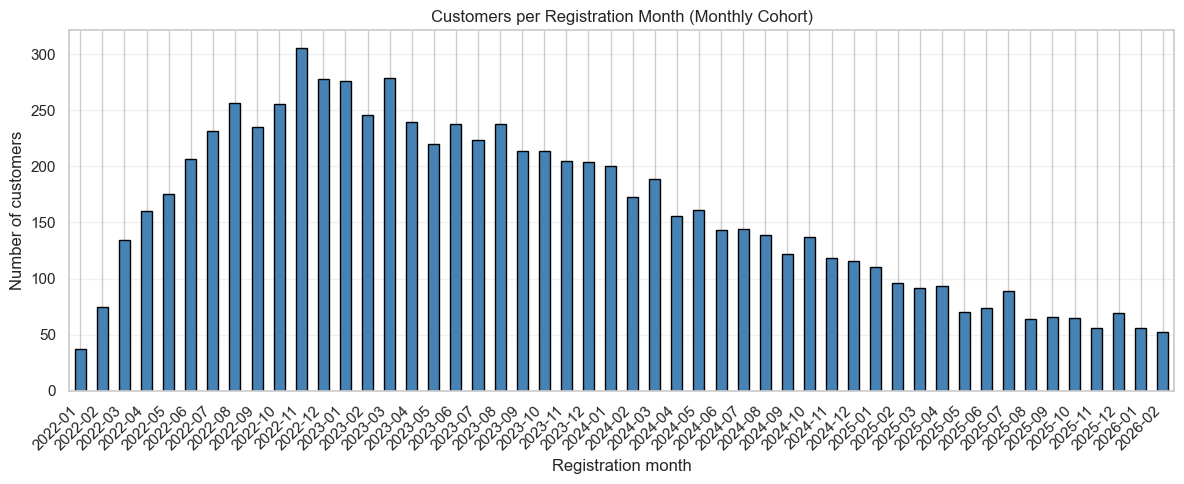

In [12]:
plt.figure(figsize=(12, 5))
monthly_cohort.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Customers per Registration Month (Monthly Cohort)")
plt.xlabel("Registration month")
plt.ylabel("Number of customers")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


Registrations follow a **Gamma(2, 360)-shaped curve** — ramping up from ~35 customers in Jan 2022, peaking around **~305 in Nov 2022**, then declining gradually to ~50–70 in late 2025. This pattern reflects the startup acquisition life-cycle baked into the generator: rapid early growth followed by a long tail. **February 2026 is the last complete cohort** (the observation window ends on 2026‑03‑01, so no March 2026 bar exists). The tail months (roughly mid-2025 onward) have meaningfully smaller cohorts and should be treated with care in any month-over-month comparison.


**Analysis window note:** For behavioral metrics (RFM, spend trends, churn signals), the recommended window is **Mar 2024 – Feb 2026** — recent enough to reflect the current product, long enough to capture meaningful patterns.

For cohort-level comparisons (retention curves), the safe core is **Jan 2023 – Sep 2025**: early cohorts (pre-2023) may reflect a different acquisition process and product maturity, while cohorts registered after Sep 2025 have fewer than 6 months of observable behavior (cold-start zone).

**Note on segment breakdowns:** `registration_date` is drawn from the **same Gamma(2, 360) curve for all segments** — no cohort-segment signal is planted. Any apparent segment trend across cohort months reflects sampling noise in small early cells (35–100 customers), not a real shift in acquisition quality over time.

<a id="q7"></a>

### 7. Age distribution

We inspect the age distribution through summary statistics (mean, median, std, skewness, kurtosis) and a histogram. Age was generated from a clipped Normal distribution (mean ≈ 35, std = 10, range 18–80) — this check validates that the distribution behaves as designed and looks plausible.

[↑ Back to summary](#summary)


Descriptive statistics for customer age:
 count    8000.000000
mean       35.213000
std        11.023932
min        18.000000
25%        27.000000
50%        35.000000
75%        42.000000
max        80.000000
Name: age, dtype: float64


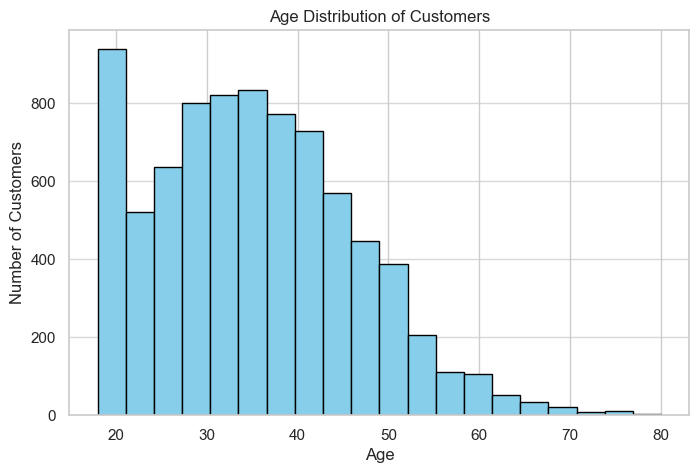

In [13]:
# Get descriptive statistics
age_desc = df_customers["age"].describe()
print("Descriptive statistics for customer age:\n", age_desc)

# Plot the histogram
plt.figure(figsize=(8, 5))
df_customers["age"].hist(bins=20, color='skyblue', edgecolor='black')
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.grid(axis='y', alpha=0.75)
plt.show()


In [14]:
# Skewness and kurtosis for age distribution
age_skewness = df_customers["age"].skew()
age_kurtosis = df_customers["age"].kurt()

print(f"Age skewness: {age_skewness:.3f}")
print(f"Age kurtosis: {age_kurtosis:.3f}")

Age skewness: 0.484
Age kurtosis: 0.013


The global age distribution is realistic for a fintech customer base: ages range from 18 to 74, with mean and  median ~35, and standard deviation = 11. Skewness of ~0.48 shows a mild right tail (slightly more older customers); kurtosis of ~0.013 indicates a slightly flatter-than-normal shape without heavy tails.

**Important context:** `age` is not drawn from a single Normal distribution in this dataset — it is drawn from **segment-specific Normals** (mean 27–42 depending on segment). The global histogram looks approximately Normal because the mixture of four overlapping distributions smooths into a single hump.

<a id="q8"></a>

### 8. State distribution

We count customers per Brazilian `state` to map geographic concentration. State probabilities were explicitly set in the generator (`STATE_PROBS` dict), so this chart also validates that the sampling matches the intended regional weights.

[↑ Back to summary](#summary)


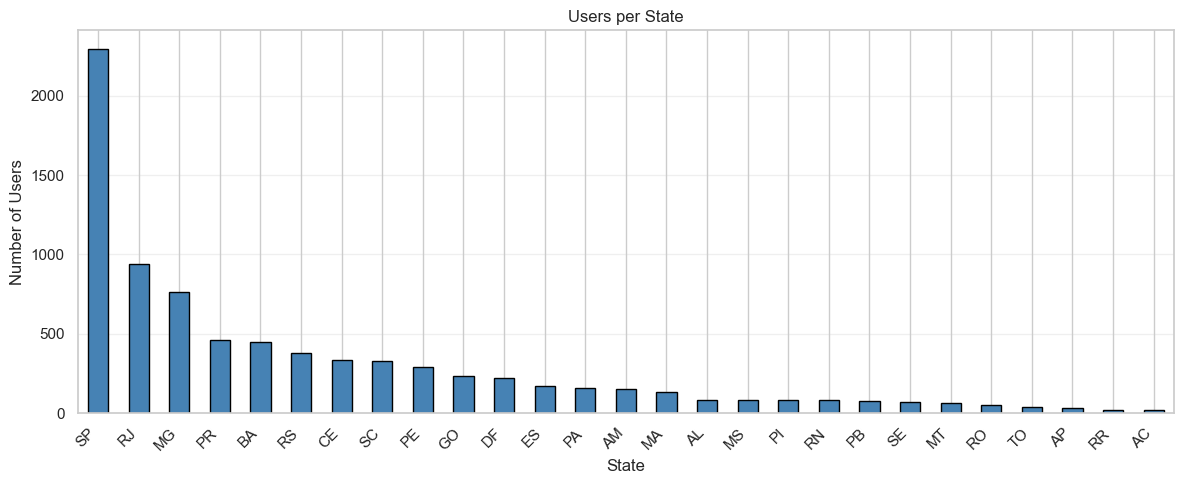

In [15]:
# Users per state
state_counts = df_customers["state"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
state_counts.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Users per State")
plt.xlabel("State")
plt.ylabel("Number of Users")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Users per state — Customer counts are very uneven: SP dominates (~2.3k), with RJ and MG next; several states form a mid tail, and AC, AP, RR (and similar) are barely visible. That pattern matches heavy Southeast weighting and a long tail of small-N states, so any story or model by state should treat SP/RJ/MG as high-signal cells and rare states as low sample size.

<a id="q9"></a>

### 9. Acquisition channel × state (top states — 70% of users)

We want to understand whether different **acquisition channels** are more or less prevalent in specific regions. Because most Brazilian states have very few customers, we **restrict the view to the top states that together account for ≥ 70% of the user base** (cumulative share), keeping the chart readable and statistically meaningful.

[↑ Back to summary](#summary)


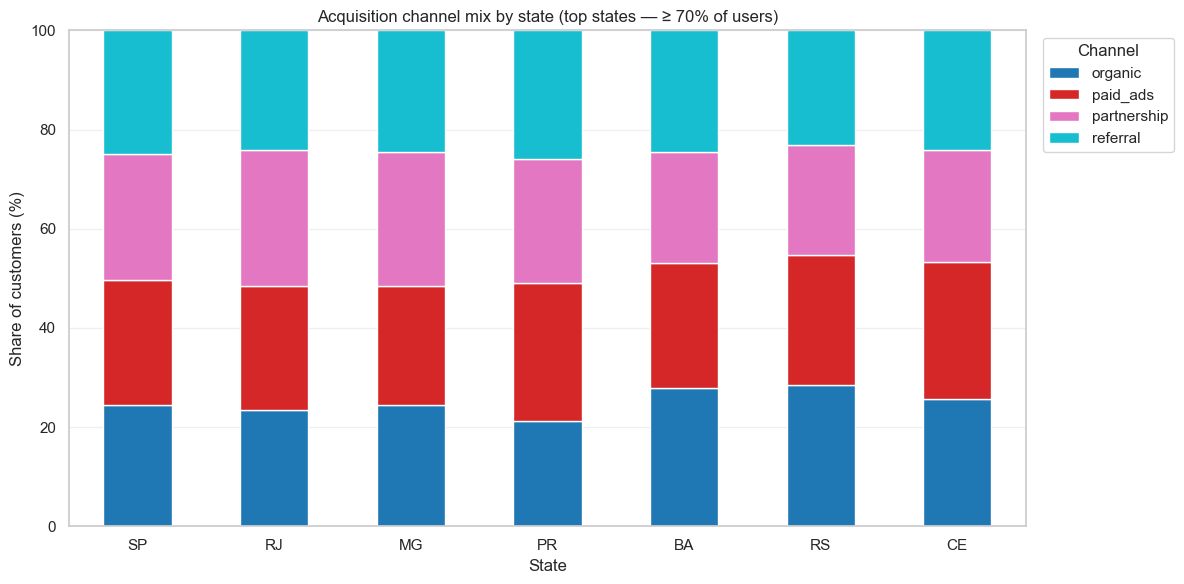


Top states (≥ 70% cumulative): ['SP', 'RJ', 'MG', 'PR', 'BA', 'RS', 'CE']
Cumulative share: 70.3%


In [16]:
# ── Acquisition channel × state (top states covering ≥ 70% of users) ────────

# Identify top states that together reach ≥ 70% cumulative share
state_counts = df_customers["state"].value_counts()
state_share  = state_counts / state_counts.sum()
cumulative   = state_share.cumsum()
top_states   = cumulative[cumulative <= 0.70].index.tolist()
# Include the next state that crosses the 70% threshold
if len(top_states) < len(cumulative):
    top_states.append(cumulative.index[len(top_states)])

df_top = df_customers[df_customers["state"].isin(top_states)].copy()

# Relative % of each channel within each top state
channel_by_state = (
    df_top.groupby(["state", "acquisition_channel"])
    .size()
    .unstack(fill_value=0)
)
channel_by_state_pct = channel_by_state.div(channel_by_state.sum(axis=1), axis=0) * 100
# Sort states by total users (largest first)
channel_by_state_pct = channel_by_state_pct.loc[
    state_counts[top_states].sort_values(ascending=False).index
]

# Stacked bar chart
ax = channel_by_state_pct.plot(
    kind="bar", stacked=True,
    figsize=(12, 6),
    colormap="tab10",
    edgecolor="white",
)
ax.set_title("Acquisition channel mix by state (top states — ≥ 70% of users)")
ax.set_xlabel("State")
ax.set_ylabel("Share of customers (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Channel", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTop states (≥ 70% cumulative): {top_states}")
print(f"Cumulative share: {state_share[top_states].sum():.1%}")


The stacked bars show that **channel mix is broadly similar across top states** — no single state appears to be dominated exclusively by one channel. This is expected because the generator assigns channels using a synthetic **segment-channel bias model** (channel economics + segment propensity), not a geography-specific rule. So geographic variation mostly reflects the **segment composition of each state** rather than a deliberate regional strategy. Any channel divergence between states is therefore a signal of **segment skew** in that state, not a separate marketing decision. In a real dataset, meaningful differences here would motivate **state-level channel attribution** and budget re-allocation.


<a id="q10"></a>

### 10. Acquisition channel × age (lifecycle bands)

We group `age` into **standard lifecycle bands** used in retail and digital banking reporting:

- **18–24** — young adults (early career, high digital adoption)
- **25–34** — core millennial segment (typical primary fintech target)
- **35–44** — established professionals and family formation
- **45–54** — mid-career / peak earning years
- **55+** — pre-retirement and older customers

For each band we show the **share of customers by acquisition channel** (each stacked bar sums to 100%), so we can compare channel mix across life stages without being skewed by how many people fall in each band.

[↑ Back to summary](#summary)


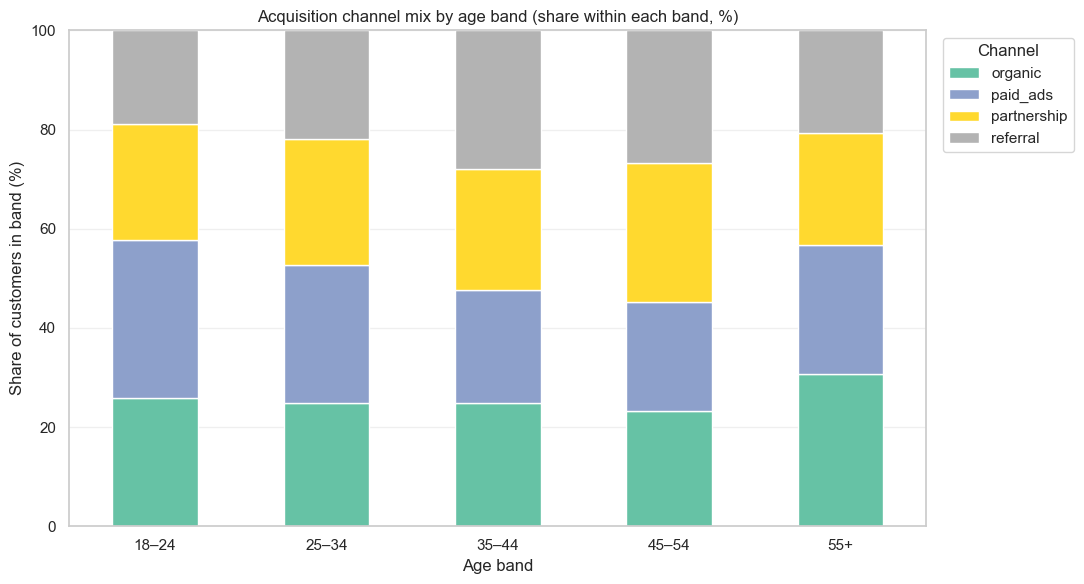

acquisition_channel  organic  paid_ads  partnership  referral
age_band                                                     
18–24                    377       466          342       275
25–34                    627       705          643       557
35–44                    611       559          597       686
45–54                    267       252          322       308
55+                      125       105           92        84


In [17]:
# ── Acquisition channel × age band (lifecycle) ─────────────────────────────

# Business-oriented bands: align with common CRM / campaign segmentation
df_age = df_customers.copy()
df_age["age_band"] = pd.cut(
    df_age["age"],
    bins=[17, 24, 34, 44, 54, 120],
    labels=["18–24", "25–34", "35–44", "45–54", "55+"],
    right=True,
)

# Relative % of each channel within each age band (readable mix comparison)
ch_by_band = (
    df_age.groupby(["age_band", "acquisition_channel"], observed=True)
    .size()
    .unstack(fill_value=0)
)
ch_by_band_pct = ch_by_band.div(ch_by_band.sum(axis=1), axis=0) * 100

ax = ch_by_band_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6),
    colormap="Set2",
    edgecolor="white",
)
ax.set_title("Acquisition channel mix by age band (share within each band, %)")
ax.set_xlabel("Age band")
ax.set_ylabel("Share of customers in band (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Channel", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(ch_by_band.astype(int).rename_axis(index="age_band").to_string())


Channel mix is **similar across age bands**, and the reason is structural: in this generator, `acquisition_channel` is sampled from **segment-specific probabilities**, not from age. Age bands show similar channel mixes because **segment composition shifts gradually across bands** — not because there is a direct age-channel rule. The channel mix in the 18–24 band looks similar to the 35–44 band because each band contains a similar *weighted blend* of segments (the weights shift, but not enough to produce a clearly different channel mix).

For the view that *does* shift clearly with age — the **segment mix within each band** — see item **13b** below.

<a id="q11"></a>

### 11. Acquisition channel × acquisition cost (CAC by channel)

We compare the **distribution of `acquisition_cost`** (customer acquisition cost, BRL) across **acquisition channels**. **Boxplots** show median, quartiles, and outliers in one view — so we can judge whether channel economics differ in level and spread, not only by a single average.

[↑ Back to summary](#summary)


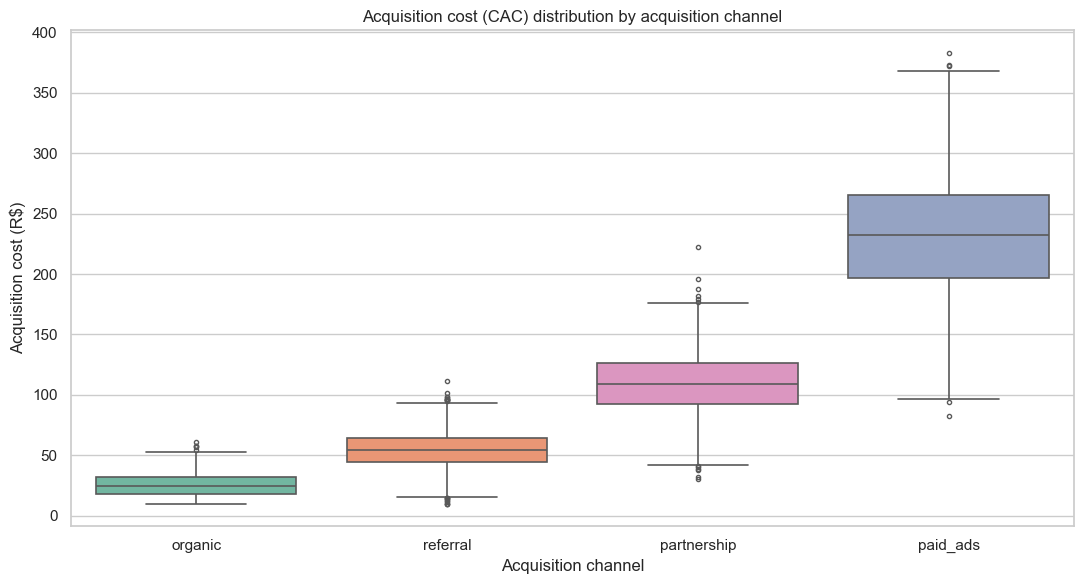

                        n    mean  median    std     q25     q75
acquisition_channel                                             
organic              2007   25.06   24.66   9.63   17.50   31.94
referral             1910   54.71   54.54  15.09   44.42   64.09
partnership          1996  109.46  109.09  24.98   92.30  126.20
paid_ads             2087  231.00  232.53  50.42  197.03  265.82


In [30]:
# ── Acquisition channel × acquisition_cost (CAC by channel) ──────────────────

# Order channels from lowest to highest typical CAC (matches generator economics)
channel_order = ["organic", "referral", "partnership", "paid_ads"]

plt.figure(figsize=(11, 6))
sns.boxplot(
    data=df_customers,
    x="acquisition_channel",
    y="acquisition_cost",
    order=channel_order,
    hue="acquisition_channel",
    palette="Set2",
    linewidth=1.2,
    fliersize=3,
    dodge=False,
    legend=False,
)
plt.title("Acquisition cost (CAC) distribution by acquisition channel")
plt.xlabel("Acquisition channel")
plt.ylabel("Acquisition cost (R$)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

cac_summary = (
    df_customers.groupby("acquisition_channel", observed=True)["acquisition_cost"]
    .agg(
        n="count",
        mean="mean",
        median="median",
        std="std",
        q25=lambda s: s.quantile(0.25),
        q75=lambda s: s.quantile(0.75),
    )
    .reindex(channel_order)
)
print(cac_summary.round(2).to_string())


**Takeaway:** The boxplots separate cleanly by channel — **organic** has the lowest median and tightest IQR, **referral** and **partnership** sit in the middle, and **paid_ads** is highest with the widest spread. That lines up with how this dataset is built: after each customer draws an `acquisition_channel`, `acquisition_cost` is sampled from a **channel-specific Normal profile** (then floored at R$ 10), so CAC is a direct readout of parameterized channel economics rather than geography or age. In a real portfolio, persistent mis-ordering versus benchmarks would warrant checking attribution, incentives, and mix shifts before using CAC in LTV or payback models.


<a id="q12"></a>

### 12. State × age band

This is a **null-result validation**, not a business insight. In the generator, `state` is drawn from `STATE_PROBS` independently of `age` and `true_segment`. We expect no systematic relationship between state and age band.

We use the **same top states** (≥70% cumulative) and **same age bands** as items 12 and 13. The heatmap shows the percentage of customers in each age band per state (rows sum to 100%). We then confirm the null result with a chi-square test of independence.

[↑ Back to summary](#summary)

Customer counts — state × age band (top states only):

age_band  18–24  25–34  35–44  45–54  55+
state                                    
SP          409    722    728    321  118
RJ          165    298    275    147   57
MG          141    237    227    118   41
PR           93    149    127     68   22
BA           76    140    145     67   18
RS           68    118    126     47   19
CE           58     98    107     48   25

Top states (≥ 70% cumulative): ['SP', 'RJ', 'MG', 'PR', 'BA', 'RS', 'CE']
Cumulative share of base: 70.3%


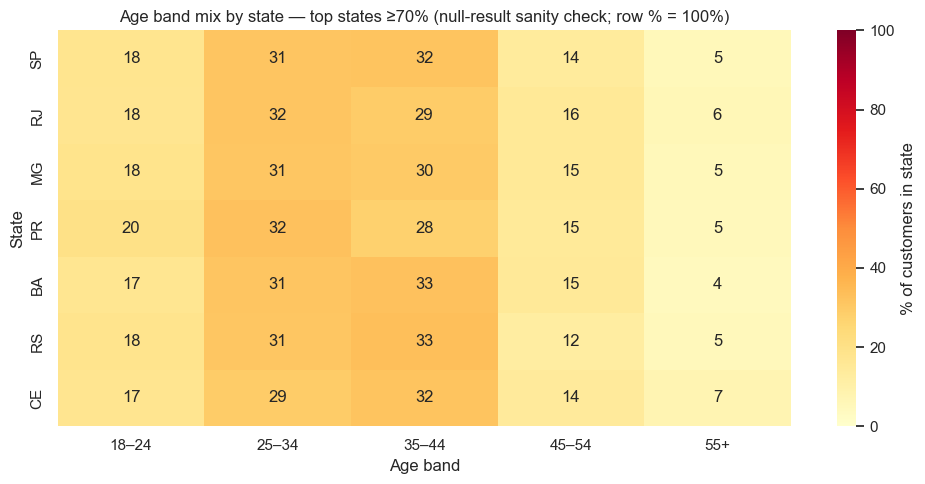


Chi-square test of independence (state × age band):
  chi2 = 15.63,  p-value = 0.9009,  df = 24
  Cramér's V = 0.0264  (effect size; 0 = no association)
  p > 0.05 — confirms no significant association between state and age band.


In [20]:
# ── State × age band (top states ≥70% + same bands as item 13) ────────────
from scipy import stats
import numpy as np

# Top states — identical logic to item 12
state_counts = df_customers["state"].value_counts()
state_share = state_counts / state_counts.sum()
cumulative = state_share.cumsum()
top_states = cumulative[cumulative <= 0.70].index.tolist()
if len(top_states) < len(cumulative):
    top_states.append(cumulative.index[len(top_states)])

df_sa = df_customers[df_customers["state"].isin(top_states)].copy()

# Age bands — identical bins/labels to item 13
df_sa["age_band"] = pd.cut(
    df_sa["age"],
    bins=[17, 24, 34, 44, 54, 120],
    labels=["18–24", "25–34", "35–44", "45–54", "55+"],
    right=True,
)

band_order = ["18–24", "25–34", "35–44", "45–54", "55+"]

# Counts and row-% (mix within state)
ct_counts = pd.crosstab(df_sa["state"], df_sa["age_band"])
state_row_order = state_counts[top_states].sort_values(ascending=False).index
ct_counts = ct_counts.reindex(index=state_row_order)
ct_counts = ct_counts.reindex(columns=[b for b in band_order if b in ct_counts.columns])

ct_pct = ct_counts.div(ct_counts.sum(axis=1), axis=0) * 100

print("Customer counts — state × age band (top states only):\n")
print(ct_counts.astype(int).to_string())
print(f"\nTop states (≥ 70% cumulative): {list(top_states)}")
print(f"Cumulative share of base: {state_share[top_states].sum():.1%}")

fig_h = max(5.0, len(ct_pct) * 0.45)
fig, ax = plt.subplots(figsize=(10, fig_h))
sns.heatmap(
    ct_pct,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    ax=ax,
    vmin=0,
    vmax=100,
    cbar_kws={"label": "% of customers in state"},
)
ax.set_title(
    "Age band mix by state — top states ≥70% (null-result sanity check; row % = 100%)"
)
ax.set_xlabel("Age band")
ax.set_ylabel("State")
plt.tight_layout()
plt.show()

# ── Chi-square test of independence ──────────────────────────────────────────
chi2, p_val, dof, _ = stats.chi2_contingency(ct_counts)
n = ct_counts.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct_counts.shape) - 1)))

print(f"\nChi-square test of independence (state × age band):")
print(f"  chi2 = {chi2:.2f},  p-value = {p_val:.4f},  df = {dof}")
print(f"  Cramér's V = {cramers_v:.4f}  (effect size; 0 = no association)")
if p_val < 0.05:
    print(f"  p < 0.05 — statistically significant, but Cramér's V ≈ 0 means the effect size is negligible.")
    print(f"  With {n:,} customers across {ct_counts.shape[0]} states × {ct_counts.shape[1]} bands, the test has high power")
    print(f"  and will flag sampling noise as 'significant'. Cramér's V is the relevant metric here.")
else:
    print(f"  p > 0.05 — confirms no significant association between state and age band.")

The heatmap rows look similar across states — consistent with the generator's independent sampling of `age` and `state`. The chi-square test provides statistical backing: **Cramér's V near 0 confirms no meaningful association** between state and age band, regardless of whether the p-value crosses 0.05 (with ~5,600 customers in 35 cells, the test has high power to flag sampling noise as significant).

This analysis is a **sanity check on the generator design**, not a source of business insight. In a production dataset with real acquisition patterns, material row differences here would support state-specific lifecycle targeting (e.g. younger-skewed regions may warrant different retention campaigns).

<a id="part-3"></a>

## Part 3 — Product Ownership as Early Behavioral Signal <a id="part3"></a>

**Goal:** use `customer_products_raw` to understand product depth as the first observable behavioral signal — before looking at any transaction history.

[↑ Back to summary](#summary)

In [ ]:
# Load customer_products_raw
query_cp = "SELECT customer_id, product_id, start_date FROM customer_products_raw where is_active = TRUE"
df_cp = pd.read_sql(query_cp, engine)
df_cp["start_date"] = pd.to_datetime(df_cp["start_date"])

# Load products catalog
df_products = pd.read_sql("SELECT product_id, product_type FROM products_raw", engine)

# Count products per customer
product_counts = (
    df_cp.groupby("customer_id")["product_id"]
    .count()
    .reset_index(name="product_count")
)

df_with_products = df_customers.merge(product_counts, on="customer_id", how="left")
df_with_products["product_count"] = df_with_products["product_count"].fillna(0).astype(int)

print(f"Customers with ≥1 product: {(df_with_products['product_count'] > 0).sum():,}")
print(df_with_products["product_count"].describe())

Customers with ≥1 product: 7,269
count    8000.000000
mean        2.042125
std         1.183121
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         5.000000
Name: product_count, dtype: float64


<a id="q13"></a>

### 13. Product count distribution

Is this customer base broadly or narrowly engaged at the product level?

[↑ Back to summary](#summary)

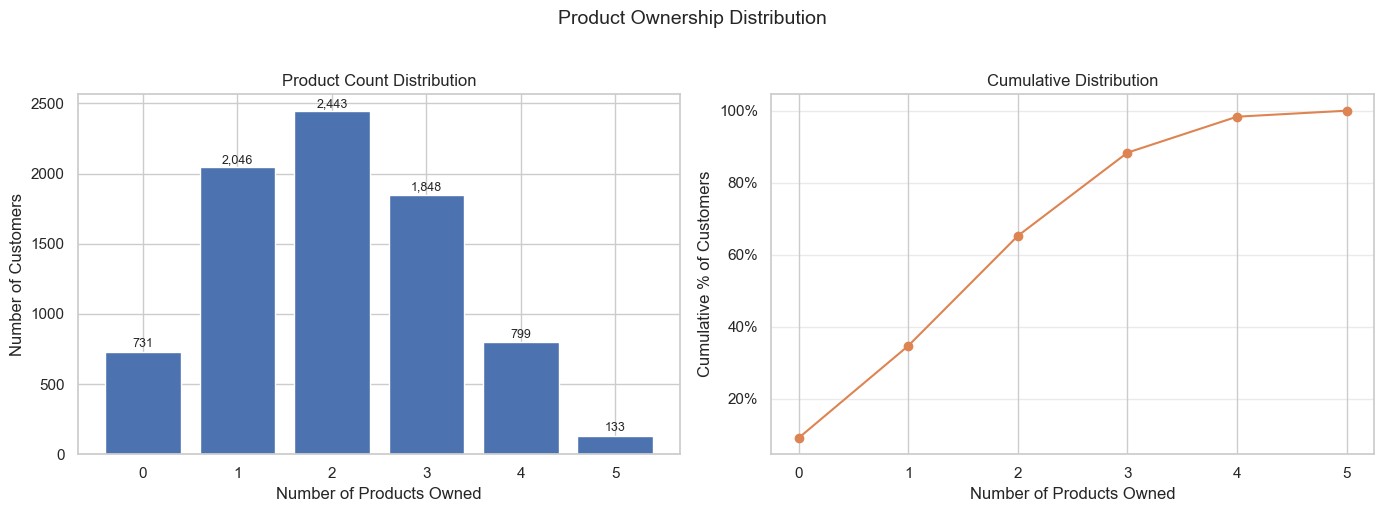


Customers with 1 product only: 2,046 (25.6%)
Customers with 2+ products: 5,223 (65.3%)


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: distribution of product counts
prod_dist = df_with_products["product_count"].value_counts().sort_index()
axes[0].bar(prod_dist.index, prod_dist.values, color="#4C72B0", edgecolor="white")
axes[0].set_xlabel("Number of Products Owned")
axes[0].set_ylabel("Number of Customers")
axes[0].set_title("Product Count Distribution")
for bar, val in zip(axes[0].patches, prod_dist.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f"{val:,}", ha="center", va="bottom", fontsize=9)

# Right: cumulative % 
cumulative = (prod_dist.values.cumsum() / prod_dist.values.sum() * 100)
axes[1].plot(prod_dist.index, cumulative, marker="o", color="#DD8452")
axes[1].set_xlabel("Number of Products Owned")
axes[1].set_ylabel("Cumulative % of Customers")
axes[1].set_title("Cumulative Distribution")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
axes[1].grid(axis="y", alpha=0.4)

plt.suptitle("Product Ownership Distribution", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nCustomers with 1 product only: {(df_with_products['product_count'] == 1).sum():,} ({(df_with_products['product_count'] == 1).mean()*100:.1f}%)")
print(f"Customers with 2+ products: {(df_with_products['product_count'] >= 2).sum():,} ({(df_with_products['product_count'] >= 2).mean()*100:.1f}%)")

**Insight**: A bimodal distribution (peak at 1 and another at 3+) or a long right tail
signals distinct engagement tiers. Customers who own multiple products are more embedded
in the platform — a natural proxy for engagement quality before transaction data is analyzed.

<a id="q14"></a>

### 14. Multi-product customers by acquisition channel

Do certain channels bring customers who are broader adopters from day one?

[↑ Back to summary](#summary)

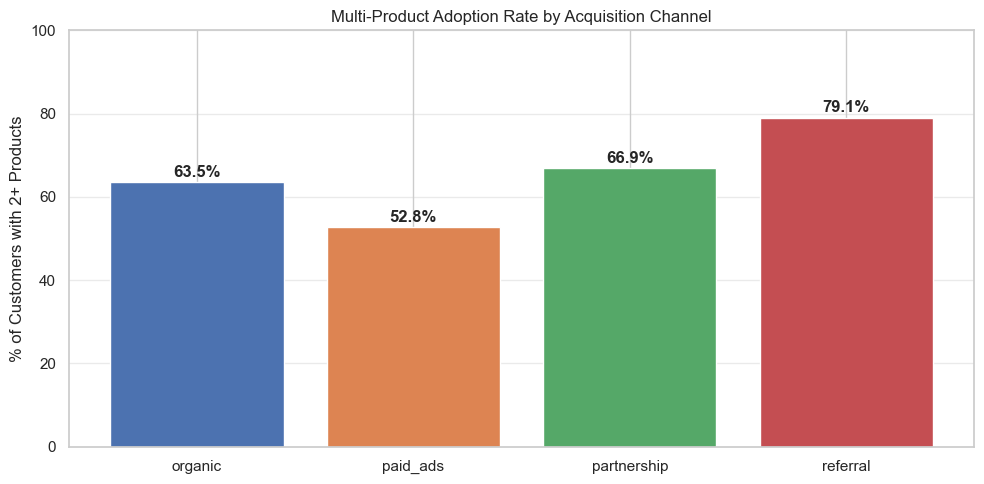

acquisition_channel  mean_products  median_products  pct_multi
            organic           1.96              2.0      63.53
           paid_ads           1.69              2.0      52.80
        partnership           2.09              2.0      66.93
           referral           2.47              3.0      79.06


In [ ]:
channel_products = (
    df_with_products
    .groupby("acquisition_channel")["product_count"]
    .agg(
        mean_products="mean",
        median_products="median",
        pct_multi=lambda x: (x >= 2).mean() * 100
    )
    .round(2)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(channel_products["acquisition_channel"],
              channel_products["pct_multi"],
              color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
ax.set_ylabel("% of Customers with 2+ Products")
ax.set_title("Multi-Product Adoption Rate by Acquisition Channel")
for bar, val in zip(bars, channel_products["pct_multi"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}%", ha="center", va="bottom", fontweight="bold")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

print(channel_products.to_string(index=False))

**Insight**: Channels where customers arrive with broader product portfolios are acquiring
more committed users. This is an observable channel quality signal independent of transaction
behavior — a complement to the CAC metric in Item 12.

<a id="q15"></a>

### 15. Product ownership vs. customer tenure

Does holding more products protect against early churn?

[↑ Back to summary](#summary)

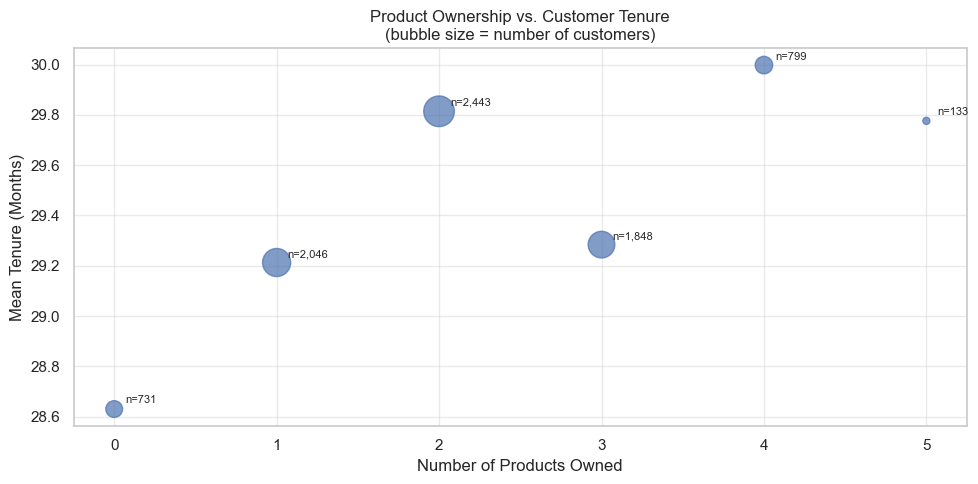

 product_count  mean_tenure  customer_count
             0    28.630643             731
             1    29.213001            2046
             2    29.814081            2443
             3    29.284091            1848
             4    29.997622             799
             5    29.775940             133


In [ ]:
# Tenure = months from registration to most recent registration date in dataset
reference_date = df_customers["registration_date"].max()
df_with_products["tenure_months"] = (
    (reference_date - df_with_products["registration_date"]).dt.days / 30.44
).round(1)

tenure_by_products = (
    df_with_products
    .groupby("product_count")["tenure_months"]
    .agg(mean_tenure="mean", customer_count="count")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(
    tenure_by_products["product_count"],
    tenure_by_products["mean_tenure"],
    s=tenure_by_products["customer_count"] / 5,
    alpha=0.7, color="#4C72B0"
)
ax.set_xlabel("Number of Products Owned")
ax.set_ylabel("Mean Tenure (Months)")
ax.set_title("Product Ownership vs. Customer Tenure\n(bubble size = number of customers)")
ax.grid(alpha=0.4)
for _, row in tenure_by_products.iterrows():
    ax.annotate(f"n={int(row['customer_count']):,}",
                (row["product_count"], row["mean_tenure"]),
                textcoords="offset points", xytext=(8, 4), fontsize=8)
plt.tight_layout()
plt.show()

print(tenure_by_products.to_string(index=False))

**Insight**: If customers with more products also have longer tenure, product cross-sell
is both a signal of engagement **and** a driver of retention — not just a revenue opportunity.
This hypothesis feeds directly into the clustering analysis in Notebook 3, where product
depth will be one of the features evaluated alongside RFM scores.

> **→ Next step**: Notebook 2 will examine temporal behavior (cohort retention, recency tiers,
> first-90-day fingerprint) to build the full behavioral picture before clustering.

---

## Notebook summary — what we covered

This notebook implements **STEP 1 ("Who do we have?")** on `customers_raw` and `customer_products_raw` using a **discovery-first approach** — no `true_segment` labels.

### Part 1 — Data quality checks (items 1–5)

- **Load & structure:** Supabase extract, `df.info()`, missing values, shape, duplicate checks.

### Part 2 — Customer profile (items 6–12)

- **Registration cohorts (item 6):** Gamma-shaped acquisition curve peaking Nov 2022, decaying into 2026.
- **Age & state (items 7–8):** Mean age ~34.5; SP dominates with ~2.3k customers.
- **Channel × geography & age (items 9–10):** Channel mix broadly similar across states and age bands.
- **CAC by channel (item 11):** Each channel has a distinct cost profile — observable without labels.
- **State × age null check (item 12):** No pattern — confirms independent geographic/age sampling.

### Part 3 — Product ownership signals (items 13–15)

- **Product count distribution (item 13):** Shape reveals engagement tiers.
- **Multi-product rate by channel (item 14):** Channel quality proxy independent of transactions.
- **Product depth vs. tenure (item 15):** Hypothesis: broader ownership → longer retention.

> For ground-truth validation (how each segment behaves), see `EDA_Validation_Fake_Dataset.ipynb`.
> For transaction-based behavioral analysis, see Notebook 2.
